In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [100]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

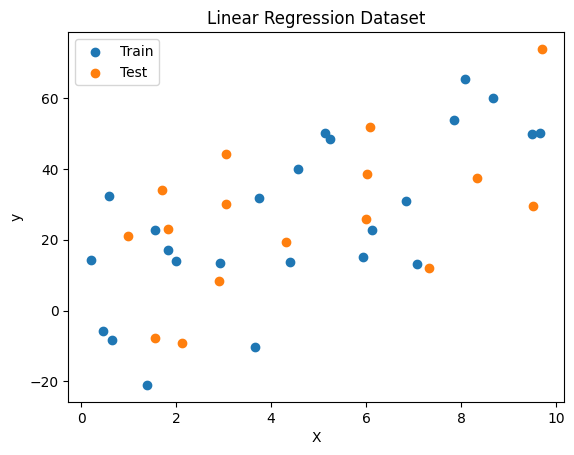

In [101]:
np.random.seed(42)
n = 40
X = np.sort(np.random.uniform(0, 10, n))
noise = np.random.normal(0, 20, n)
y = 3*X+14 + noise
X = X.reshape(-1, 1)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42
)
plt.scatter(X_train, y_train, label="Train")
plt.scatter(X_test, y_test, label="Test")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression Dataset")
plt.legend()
plt.show()

In [102]:
model = Sequential()
model.add(Dense(128, activation="relu", input_shape=(1,)))
model.add(Dense(128, activation="relu"))
model.add(Dense(32,activation='relu'))
model.add(Dense(1, activation="linear"))

model.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_72 (Dense)                │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,929 (81.75 KB)

 Trainable params: 20,929 (81.75 KB)

 Non-trainable params: 0 (0.00 B)

In [103]:
adam=Adam(learning_rate=0.001)
model.compile(optimizer='adam',loss='mse',metrics=['mse'])
history=model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=1000,verbose=False)

In [104]:
_, train_mse=model.evaluate(X_train,y_train,verbose=False)
_, test_mse=model.evaluate(X_test,y_test,verbose=False)
print(f"Train MSE: {train_mse}")
print(f"Test MSE: {test_mse}")

Train MSE: 261.95745849609375
Test MSE: 318.0267639160156


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


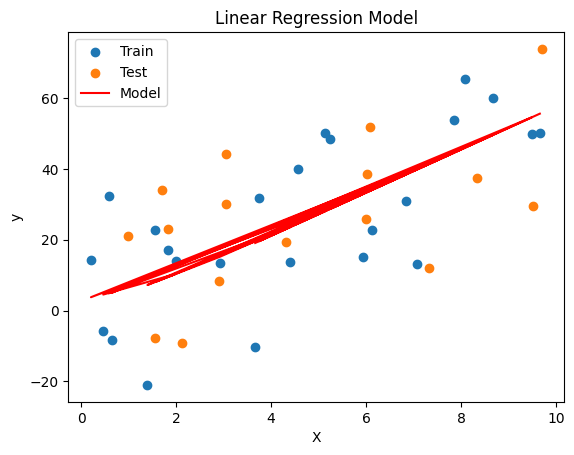

In [105]:
plt.scatter(X_train, y_train, label="Train")
plt.scatter(X_test, y_test, label="Test")
plt.plot(X_train, model.predict(X_train), color="red", label="Model")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression Model")
plt.legend()
plt.show()

# **Droupout**

In [110]:
model=Sequential()
model.add(Dense(128,activation='relu',input_shape=(1,)))
model.add(Dropout(0.3))
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(32,activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1,activation='linear'))
model.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_80 (Dense)                │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_81 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_82 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_83 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,929 (81.75 KB)

 Trainable params: 20,929 (81.75 KB)

 Non-trainable params: 0 (0.00 B)

In [111]:
adam=Adam(learning_rate=0.001)
model.compile(optimizer='adam',loss='mse',metrics=['mse'])
history=model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=1000,verbose=False)


In [113]:
_, train_mse=model.evaluate(X_train,y_train,verbose=False)
_, test_mse=model.evaluate(X_test,y_test,verbose=False)
print(f"Train MSE: {train_mse}")
print(f"Test MSE: {test_mse}")

Train MSE: 265.26873779296875
Test MSE: 307.2660217285156


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


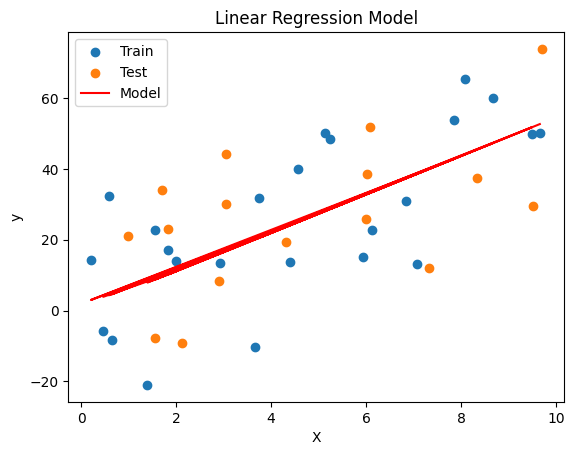

In [112]:
plt.scatter(X_train, y_train, label="Train")
plt.scatter(X_test, y_test, label="Test")
plt.plot(X_train, model.predict(X_train), color="red", label="Model")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression Model")
plt.legend()
plt.show()